# Assignment 2: From Trees to Neural Networks
**Name:** Anh Lam  
**UNI:** adl2196  
**Dataset:** Home Credit Default Risk (Kaggle)  

**Task:** Predict whether an applicant will repay a loan using application, credit, and behavioral data.

## 1. Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('figures', exist_ok=True)
print('All imports successful!')

All imports successful!


### 1.1 Load and Explore Data

In [2]:
df = pd.read_csv('data/application_train.csv')
print(f'Dataset shape: {df.shape}')
print(f'Number of features: {df.shape[1] - 2}')  # minus SK_ID_CURR and TARGET
df.head()

Dataset shape: (307511, 122)
Number of features: 120


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Target Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 0.0807 (8.07%)


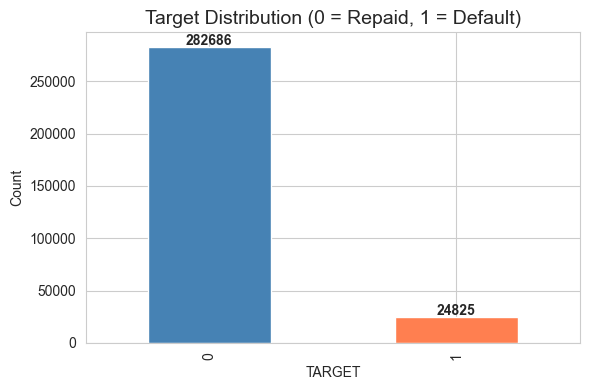

In [3]:
# Target distribution
print('Target Distribution:')
print(df['TARGET'].value_counts())
print(f'\nDefault rate: {df["TARGET"].mean():.4f} ({df["TARGET"].mean()*100:.2f}%)')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['TARGET'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target Distribution (0 = Repaid, 1 = Default)', fontsize=14)
ax.set_xlabel('TARGET')
ax.set_ylabel('Count')
for i, v in enumerate(df['TARGET'].value_counts().values):
    ax.text(i, v + 2000, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/target_distribution.png', bbox_inches='tight')
plt.show()

In [4]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f'Columns with missing values: {len(missing_pct)} out of {df.shape[1]}')
print(f'\nTop 15 columns by missing %:')
print(missing_pct.head(15).to_string())

Columns with missing values: 67 out of 122

Top 15 columns by missing %:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784


### 1.2 Handle Missing Values and Inconsistent Types

In [5]:
# Drop SK_ID_CURR (ID column, not a feature)
df = df.drop('SK_ID_CURR', axis=1)

# Fix anomalous values
# DAYS_EMPLOYED has 365243 for unemployed/retired — replace with NaN
print(f'DAYS_EMPLOYED anomalous values: {(df["DAYS_EMPLOYED"] == 365243).sum()}')
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# CODE_GENDER has 'XNA' — treat as missing
print(f'CODE_GENDER XNA values: {(df["CODE_GENDER"] == "XNA").sum()}')
df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)

# ORGANIZATION_TYPE has 'XNA' — treat as missing
print(f'ORGANIZATION_TYPE XNA values: {(df["ORGANIZATION_TYPE"] == "XNA").sum()}')
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA', np.nan)

# Drop columns with >40% missing values (too much information loss)
missing_pct_cols = df.isnull().sum() / len(df)
cols_to_drop = missing_pct_cols[missing_pct_cols > 0.40].index.tolist()
print(f'\nDropping {len(cols_to_drop)} columns with >40% missing values')
df = df.drop(columns=cols_to_drop)
print(f'Shape after dropping high-missing columns: {df.shape}')

DAYS_EMPLOYED anomalous values: 55374
CODE_GENDER XNA values: 4
ORGANIZATION_TYPE XNA values: 55374



Dropping 49 columns with >40% missing values
Shape after dropping high-missing columns: (307511, 72)


### 1.3 Feature Engineering

In [6]:
# Create useful features
# Credit-to-income ratio
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

# Annuity-to-income ratio
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

# Credit-to-goods price ratio
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

# Age in years (DAYS_BIRTH is negative)
df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365.25

# Employment years
df['EMPLOYMENT_YEARS'] = (-df['DAYS_EMPLOYED']) / 365.25

# Age groups
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=[0, 25, 35, 45, 55, 65, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Income-to-children ratio
df['INCOME_PER_CHILD'] = df['AMT_INCOME_TOTAL'] / (df['CNT_CHILDREN'] + 1)

# External sources average (these are the most predictive features)
ext_cols = [c for c in df.columns if 'EXT_SOURCE' in c]
df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_STD'] = df[ext_cols].std(axis=1)

print(f'Shape after feature engineering: {df.shape}')
print(f'New features: CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_GOODS_RATIO,')
print(f'             AGE_YEARS, EMPLOYMENT_YEARS, AGE_GROUP, INCOME_PER_CHILD,')
print(f'             EXT_SOURCE_MEAN, EXT_SOURCE_STD')

Shape after feature engineering: (307511, 81)
New features: CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_GOODS_RATIO,
             AGE_YEARS, EMPLOYMENT_YEARS, AGE_GROUP, INCOME_PER_CHILD,
             EXT_SOURCE_MEAN, EXT_SOURCE_STD


### 1.4 Encode Categorical Variables

In [7]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('TARGET')  # TARGET is not a feature

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical columns ({len(num_cols)})')

# For columns with 2 unique values: label encode
# For columns with >2 unique values: one-hot encode
binary_cats = [c for c in cat_cols if df[c].nunique() <= 2]
multi_cats = [c for c in cat_cols if df[c].nunique() > 2]

print(f'\nBinary categorical columns: {binary_cats}')
print(f'Multi-class categorical columns: {multi_cats}')
for c in multi_cats:
    print(f'  {c}: {df[c].nunique()} unique values')

Categorical columns (13): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'AGE_GROUP']
Numerical columns (67)



Binary categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
Multi-class categorical columns: ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'AGE_GROUP']
  NAME_TYPE_SUITE: 7 unique values
  NAME_INCOME_TYPE: 8 unique values
  NAME_EDUCATION_TYPE: 5 unique values
  NAME_FAMILY_STATUS: 6 unique values
  NAME_HOUSING_TYPE: 6 unique values
  OCCUPATION_TYPE: 18 unique values
  WEEKDAY_APPR_PROCESS_START: 7 unique values
  ORGANIZATION_TYPE: 57 unique values
  AGE_GROUP: 6 unique values


In [8]:
# Label encode binary categoricals
le = LabelEncoder()
for col in binary_cats:
    df[col] = df[col].astype(str)  # handle NaN
    df[col] = le.fit_transform(df[col])

# One-hot encode multi-class categoricals (drop_first to avoid multicollinearity)
df = pd.get_dummies(df, columns=multi_cats, drop_first=True, dtype=int)

print(f'Shape after encoding: {df.shape}')

Shape after encoding: (307511, 183)


### 1.5 Train / Validation / Test Split (70 / 15 / 15)

In [9]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Second split: 50/50 of temp -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Training set:   {X_train.shape[0]:>6} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation set: {X_val.shape[0]:>6} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:       {X_test.shape[0]:>6} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTarget rates - Train: {y_train.mean():.4f}, Val: {y_val.mean():.4f}, Test: {y_test.mean():.4f}')
print(f'Number of features: {X_train.shape[1]}')

Training set:   215257 samples (70.0%)
Validation set:  46127 samples (15.0%)
Test set:        46127 samples (15.0%)

Target rates - Train: 0.0807, Val: 0.0807, Test: 0.0807
Number of features: 182


### 1.6 Imputation and Scaling (Fit on Train Only — No Data Leakage)

**Important:** All preprocessing (imputation, scaling) is fit on the training set only, then applied to validation and test sets. This prevents data leakage — we never use test/validation information during data preparation.

**Why scale for MLP but not for GBDT?** Neural networks (MLPs) use gradient-based optimization with activation functions that are sensitive to input magnitudes. If features are on vastly different scales (e.g., income in hundreds of thousands vs. binary flags), gradients will be dominated by large-scale features, causing slow/poor convergence. Standardization (zero mean, unit variance) ensures all features contribute equally. Tree-based models like XGBoost split on feature thresholds and are invariant to monotonic transformations — scaling has no effect on their decisions.

In [10]:
# Impute missing values — fit on train only
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f'Missing values after imputation:')
print(f'  Train: {X_train_imp.isnull().sum().sum()}')
print(f'  Val:   {X_val_imp.isnull().sum().sum()}')
print(f'  Test:  {X_test_imp.isnull().sum().sum()}')

# For GBDT — use imputed data
X_train_gbdt = X_train_imp.copy()
X_val_gbdt = X_val_imp.copy()
X_test_gbdt = X_test_imp.copy()

# For MLP — standardize features (fit on train only)
scaler = StandardScaler()
X_train_mlp = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train.columns, index=X_train.index)
X_val_mlp = pd.DataFrame(scaler.transform(X_val_imp), columns=X_val.columns, index=X_val.index)
X_test_mlp = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test.columns, index=X_test.index)

print(f'\nMLP feature scaling (StandardScaler) — fit on train only:')
print(f'  Train mean: {X_train_mlp.mean().mean():.6f}, std: {X_train_mlp.std().mean():.4f}')
print(f'  Val mean:   {X_val_mlp.mean().mean():.6f}, std: {X_val_mlp.std().mean():.4f}')
print(f'  Test mean:  {X_test_mlp.mean().mean():.6f}, std: {X_test_mlp.std().mean():.4f}')

Missing values after imputation:
  Train: 0
  Val:   0
  Test:  0



MLP feature scaling (StandardScaler) — fit on train only:


  Train mean: 0.000000, std: 1.0000
  Val mean:   0.000309, std: 0.9875
  Test mean:  0.000589, std: 1.0060


---
## 2. Gradient Boosted Decision Tree (GBDT) — XGBoost

### 2.1 Baseline XGBoost with Early Stopping

In [11]:
# Calculate scale_pos_weight for imbalanced dataset
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos:.2f} (ratio of negative to positive samples)')

# Baseline XGBoost model
xgb_baseline = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=50,
    n_jobs=-1
)

start_time = time.time()
xgb_baseline.fit(
    X_train_gbdt, y_train,
    eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
    verbose=50
)
xgb_train_time = time.time() - start_time

print(f'\nTraining time: {xgb_train_time:.2f}s')
print(f'Best iteration: {xgb_baseline.best_iteration}')
print(f'Best validation logloss: {xgb_baseline.best_score:.6f}')

scale_pos_weight: 11.39 (ratio of negative to positive samples)


[0]	validation_0-logloss:0.67873	validation_1-logloss:0.67887


[50]	validation_0-logloss:0.56446	validation_1-logloss:0.57424


[100]	validation_0-logloss:0.54326	validation_1-logloss:0.55958


[150]	validation_0-logloss:0.52603	validation_1-logloss:0.54857


...

[850]	validation_0-logloss:0.35513	validation_1-logloss:0.44009


[900]	validation_0-logloss:0.34576	validation_1-logloss:0.43438


[950]	validation_0-logloss:0.33692	validation_1-logloss:0.42927


[999]	validation_0-logloss:0.32896	validation_1-logloss:0.42465



Training time: 31.04s
Best iteration: 999
Best validation logloss: 0.424649


### 2.2 Training vs Validation Loss (Early Stopping)

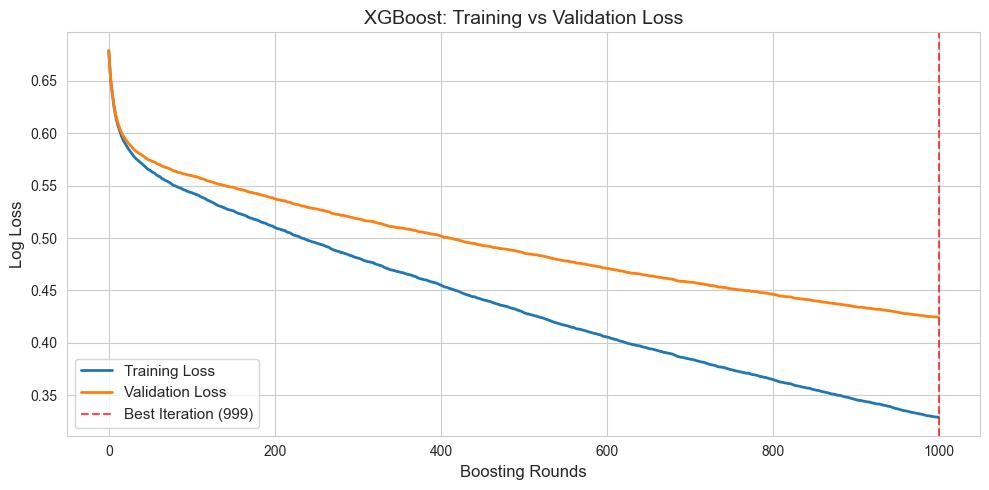

In [12]:
# Plot training vs validation loss
results = xgb_baseline.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_loss, label='Training Loss', linewidth=2)
ax.plot(val_loss, label='Validation Loss', linewidth=2)
ax.axvline(x=xgb_baseline.best_iteration, color='red', linestyle='--', alpha=0.7,
           label=f'Best Iteration ({xgb_baseline.best_iteration})')
ax.set_xlabel('Boosting Rounds', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_title('XGBoost: Training vs Validation Loss', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/xgb_train_val_loss.png', bbox_inches='tight')
plt.show()

### 2.3 Feature Importance

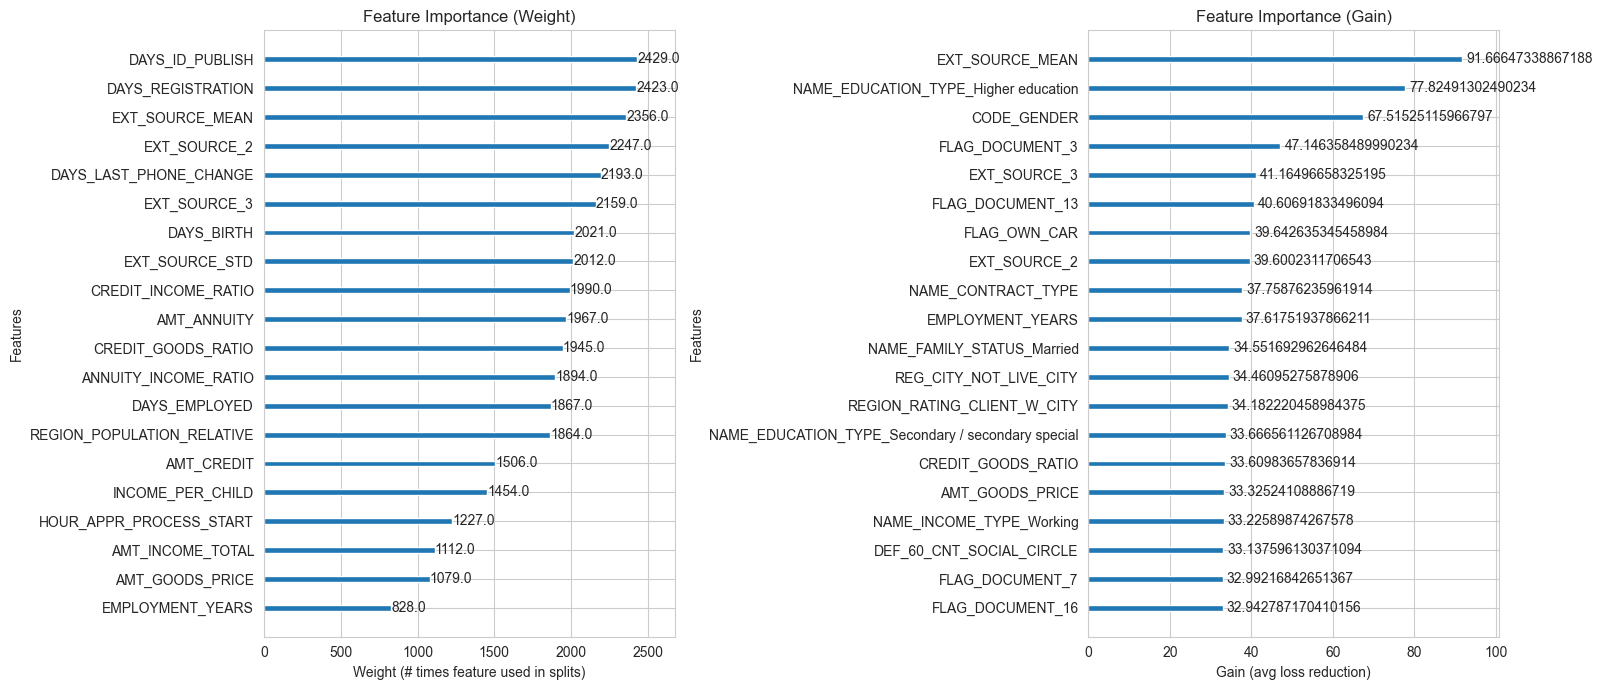

In [13]:
# Feature importance plot — top 20 features
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Weight-based importance
plot_importance(xgb_baseline, ax=axes[0], max_num_features=20,
               importance_type='weight', title='Feature Importance (Weight)')
axes[0].set_xlabel('Weight (# times feature used in splits)')

# Gain-based importance
plot_importance(xgb_baseline, ax=axes[1], max_num_features=20,
               importance_type='gain', title='Feature Importance (Gain)')
axes[1].set_xlabel('Gain (avg loss reduction)')

plt.tight_layout()
plt.savefig('figures/xgb_feature_importance.png', bbox_inches='tight')
plt.show()

### 2.4 Effect of Learning Rate

LR=0.01: Best iter=999, Best val logloss=0.556554


LR=0.1: Best iter=999, Best val logloss=0.424649


LR=0.3: Best iter=999, Best val logloss=0.354795


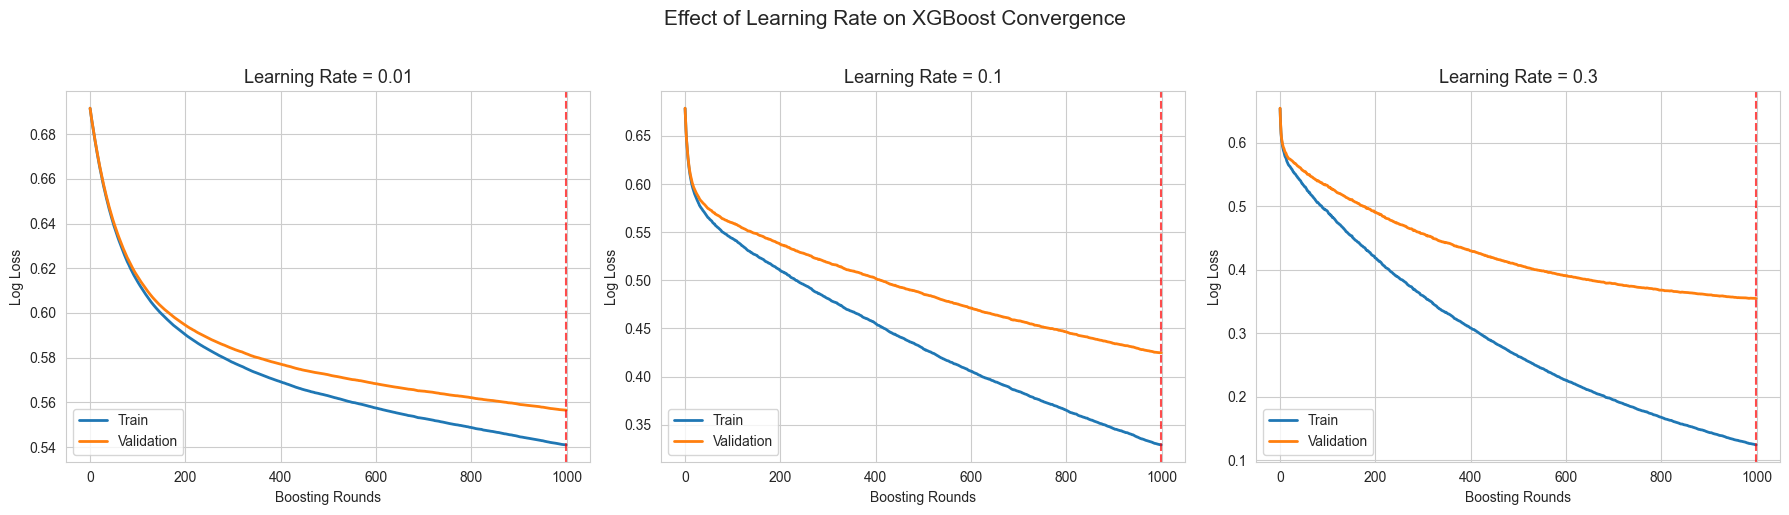

In [14]:
# Compare learning rates: 0.01, 0.1, 0.3
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, lr in enumerate(learning_rates):
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=lr,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        early_stopping_rounds=50,
        n_jobs=-1
    )
    model.fit(
        X_train_gbdt, y_train,
        eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
        verbose=False
    )
    
    res = model.evals_result()
    lr_results[lr] = {
        'model': model,
        'best_iter': model.best_iteration,
        'best_score': model.best_score,
        'train_loss': res['validation_0']['logloss'],
        'val_loss': res['validation_1']['logloss']
    }
    
    axes[i].plot(res['validation_0']['logloss'], label='Train', linewidth=2)
    axes[i].plot(res['validation_1']['logloss'], label='Validation', linewidth=2)
    axes[i].axvline(x=model.best_iteration, color='red', linestyle='--', alpha=0.7)
    axes[i].set_title(f'Learning Rate = {lr}', fontsize=13)
    axes[i].set_xlabel('Boosting Rounds')
    axes[i].set_ylabel('Log Loss')
    axes[i].legend()
    
    print(f'LR={lr}: Best iter={model.best_iteration}, Best val logloss={model.best_score:.6f}')

plt.suptitle('Effect of Learning Rate on XGBoost Convergence', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('figures/xgb_learning_rate_comparison.png', bbox_inches='tight')
plt.show()

### 2.5 Hyperparameter Exploration: max_depth, subsample, and regularization

In [15]:
# Explore max_depth effect
max_depths = [3, 5, 7, 9]
depth_results = []

for depth in max_depths:
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        early_stopping_rounds=50,
        n_jobs=-1
    )
    model.fit(X_train_gbdt, y_train,
              eval_set=[(X_val_gbdt, y_val)], verbose=False)
    
    y_pred = model.predict(X_val_gbdt)
    y_prob = model.predict_proba(X_val_gbdt)[:, 1]
    
    depth_results.append({
        'max_depth': depth,
        'best_iter': model.best_iteration,
        'val_logloss': model.best_score,
        'val_f1': f1_score(y_val, y_pred),
        'val_auc_pr': average_precision_score(y_val, y_prob)
    })

depth_df = pd.DataFrame(depth_results)
print('Max Depth Comparison:')
print(depth_df.to_string(index=False))

Max Depth Comparison:
 max_depth  best_iter  val_logloss   val_f1  val_auc_pr
         3        984     0.558323 0.265989    0.241931
         5        999     0.480804 0.275899    0.232139
         7        999     0.362450 0.276539    0.211217
         9        995     0.296262 0.203535    0.194954


In [16]:
# Explore subsample effect
subsamples = [0.5, 0.7, 0.8, 1.0]
subsample_results = []

for ss in subsamples:
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=6,
        subsample=ss,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        early_stopping_rounds=50,
        n_jobs=-1
    )
    model.fit(X_train_gbdt, y_train,
              eval_set=[(X_val_gbdt, y_val)], verbose=False)
    
    y_pred = model.predict(X_val_gbdt)
    y_prob = model.predict_proba(X_val_gbdt)[:, 1]
    
    subsample_results.append({
        'subsample': ss,
        'best_iter': model.best_iteration,
        'val_logloss': model.best_score,
        'val_f1': f1_score(y_val, y_pred),
        'val_auc_pr': average_precision_score(y_val, y_prob)
    })

ss_df = pd.DataFrame(subsample_results)
print('Subsample Comparison:')
print(ss_df.to_string(index=False))

Subsample Comparison:
 subsample  best_iter  val_logloss   val_f1  val_auc_pr
       0.5        994     0.433781 0.268374    0.211623
       0.7        999     0.425768 0.271385    0.217514
       0.8        999     0.422829 0.276839    0.216572
       1.0        999     0.439946 0.276787    0.218269


In [17]:
# Explore regularization (reg_alpha, reg_lambda)
reg_configs = [
    (0, 0), (0, 1), (0.1, 1), (1, 1), (0.1, 5), (1, 5)
]
reg_results = []

for alpha, lmbda in reg_configs:
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=alpha,
        reg_lambda=lmbda,
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        early_stopping_rounds=50,
        n_jobs=-1
    )
    model.fit(X_train_gbdt, y_train,
              eval_set=[(X_val_gbdt, y_val)], verbose=False)
    
    y_pred = model.predict(X_val_gbdt)
    y_prob = model.predict_proba(X_val_gbdt)[:, 1]
    
    reg_results.append({
        'reg_alpha': alpha,
        'reg_lambda': lmbda,
        'best_iter': model.best_iteration,
        'val_logloss': model.best_score,
        'val_f1': f1_score(y_val, y_pred),
        'val_auc_pr': average_precision_score(y_val, y_prob)
    })

reg_df = pd.DataFrame(reg_results)
print('Regularization Comparison (reg_alpha, reg_lambda):')
print(reg_df.to_string(index=False))

Regularization Comparison (reg_alpha, reg_lambda):
 reg_alpha  reg_lambda  best_iter  val_logloss   val_f1  val_auc_pr
       0.0           0        999     0.425120 0.274096    0.218895
       0.0           1        999     0.422829 0.276839    0.216572
       0.1           1        999     0.424649 0.272786    0.218735
       1.0           1        999     0.420973 0.277449    0.216466
       0.1           5        999     0.424373 0.279900    0.223445
       1.0           5        999     0.423678 0.280766    0.224116


### 2.6 Best GBDT Model — Final Evaluation on Test Set

In [18]:
# Use the baseline model for final evaluation on test set
y_pred_xgb = xgb_baseline.predict(X_test_gbdt)
y_prob_xgb = xgb_baseline.predict_proba(X_test_gbdt)[:, 1]

print('=== XGBoost — Test Set Performance ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Repaid (0)', 'Default (1)']))

xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'AUC-PR': average_precision_score(y_test, y_prob_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)
}

for metric, value in xgb_metrics.items():
    print(f'  {metric}: {value:.4f}')

print(f'\nTraining time: {xgb_train_time:.2f}s')

=== XGBoost — Test Set Performance ===
              precision    recall  f1-score   support

  Repaid (0)       0.95      0.84      0.89     42403
 Default (1)       0.20      0.47      0.28      3724

    accuracy                           0.81     46127
   macro avg       0.57      0.65      0.59     46127
weighted avg       0.89      0.81      0.84     46127

  Accuracy: 0.8061
  Precision: 0.2018
  Recall: 0.4742
  F1-Score: 0.2831
  AUC-PR: 0.2198
  ROC-AUC: 0.7374

Training time: 31.04s


---
## 3. Multi-Layer Perceptron (MLP)

### 3.1 Baseline MLP

In [19]:
# Baseline MLP
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
    verbose=True
)

start_time = time.time()
mlp_baseline.fit(X_train_mlp, y_train)
mlp_train_time = time.time() - start_time

print(f'\nTraining time: {mlp_train_time:.2f}s')
print(f'Iterations: {mlp_baseline.n_iter_}')
print(f'Final training loss: {mlp_baseline.loss_:.6f}')

Iteration 1, loss = 0.25820266
Validation score: 0.919168


Iteration 2, loss = 0.24891528
Validation score: 0.919353


Iteration 3, loss = 0.24572357
Validation score: 0.919260


Iteration 4, loss = 0.24276530
Validation score: 0.919260


Iteration 5, loss = 0.23997502
Validation score: 0.919137


...

Iteration 14, loss = 0.20334580
Validation score: 0.907616


Iteration 15, loss = 0.19965748
Validation score: 0.907523


Iteration 16, loss = 0.19649010
Validation score: 0.902072


Iteration 17, loss = 0.19263077
Validation score: 0.903930


Iteration 18, loss = 0.18988832
Validation score: 0.898139
Validation score did not improve more than tol=0.000100 for 15 consecutive epochs. Stopping.

Training time: 13.69s
Iterations: 18
Final training loss: 0.189888


### 3.2 Training Loss Curve

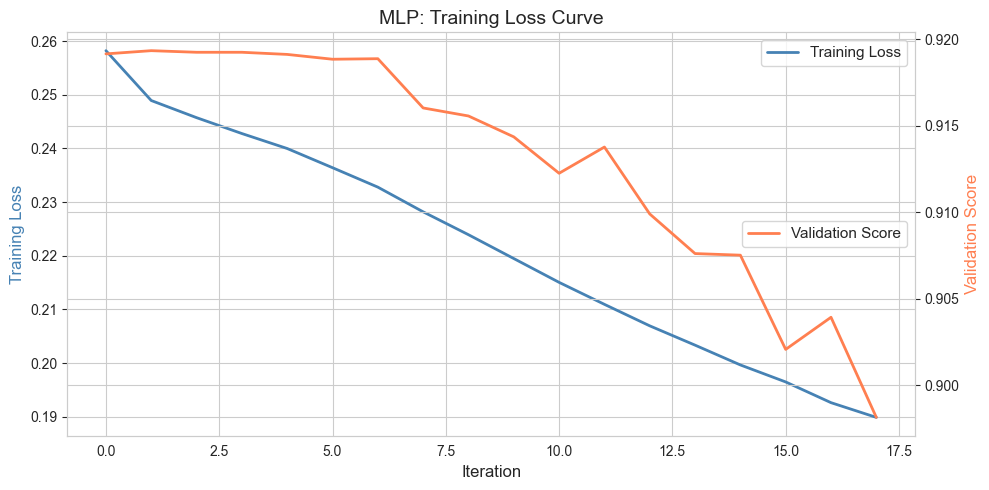

In [20]:
# Plot training loss curve
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(mlp_baseline.loss_curve_, label='Training Loss', linewidth=2, color='steelblue')
if hasattr(mlp_baseline, 'validation_scores_') and mlp_baseline.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp_baseline.validation_scores_, label='Validation Score', linewidth=2, color='coral')
    ax2.set_ylabel('Validation Score', fontsize=12, color='coral')
    ax2.legend(loc='center right', fontsize=11)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12, color='steelblue')
ax.set_title('MLP: Training Loss Curve', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig('figures/mlp_loss_curve.png', bbox_inches='tight')
plt.show()

### 3.3 Effect of Network Depth/Width

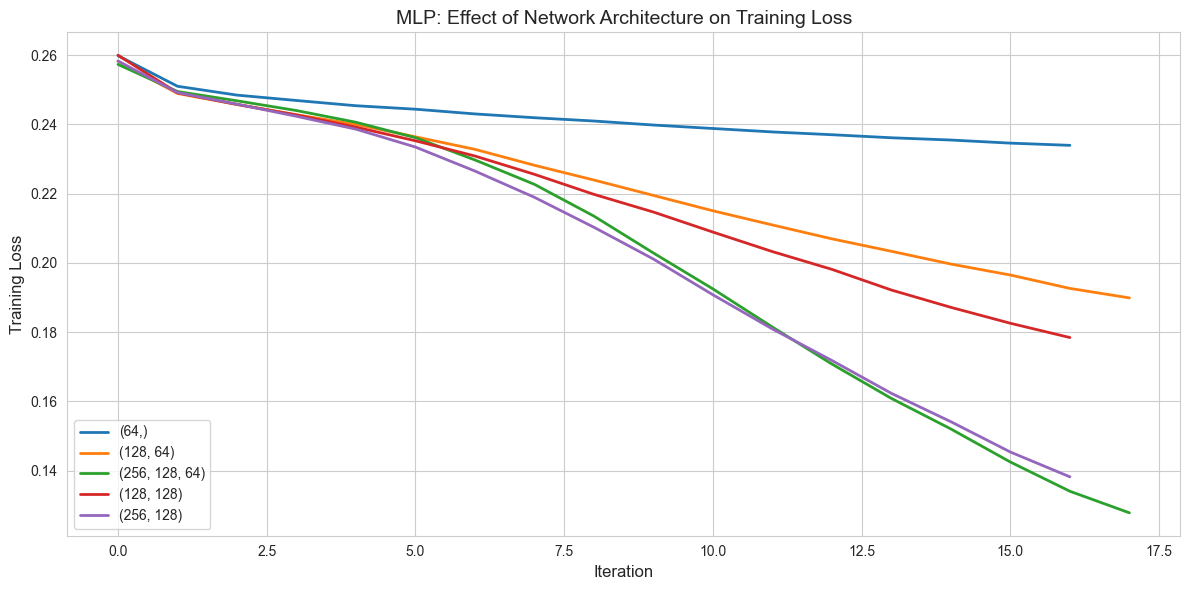

Architecture Comparison:
  architecture  iterations   val_f1  val_auc_pr  val_accuracy
         (64,)          17 0.012215    0.215477      0.919353
     (128, 64)          18 0.010619    0.217513      0.919201
(256, 128, 64)          18 0.008545    0.225993      0.919505
    (128, 128)          17 0.008536    0.220347      0.919418
    (256, 128)          17 0.016398    0.222271      0.919375


In [21]:
# Compare different architectures
architectures = [
    (64,),
    (128, 64),
    (256, 128, 64),
    (128, 128),
    (256, 128)
]

arch_results = []
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
        verbose=False
    )
    model.fit(X_train_mlp, y_train)
    
    y_pred = model.predict(X_val_mlp)
    y_prob = model.predict_proba(X_val_mlp)[:, 1]
    
    arch_results.append({
        'architecture': str(arch),
        'iterations': model.n_iter_,
        'val_f1': f1_score(y_val, y_pred),
        'val_auc_pr': average_precision_score(y_val, y_prob),
        'val_accuracy': accuracy_score(y_val, y_pred)
    })
    
    ax.plot(model.loss_curve_, label=f'{arch}', linewidth=2)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('MLP: Effect of Network Architecture on Training Loss', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/mlp_architecture_comparison.png', bbox_inches='tight')
plt.show()

arch_df = pd.DataFrame(arch_results)
print('Architecture Comparison:')
print(arch_df.to_string(index=False))

### 3.4 Effect of Activation Function

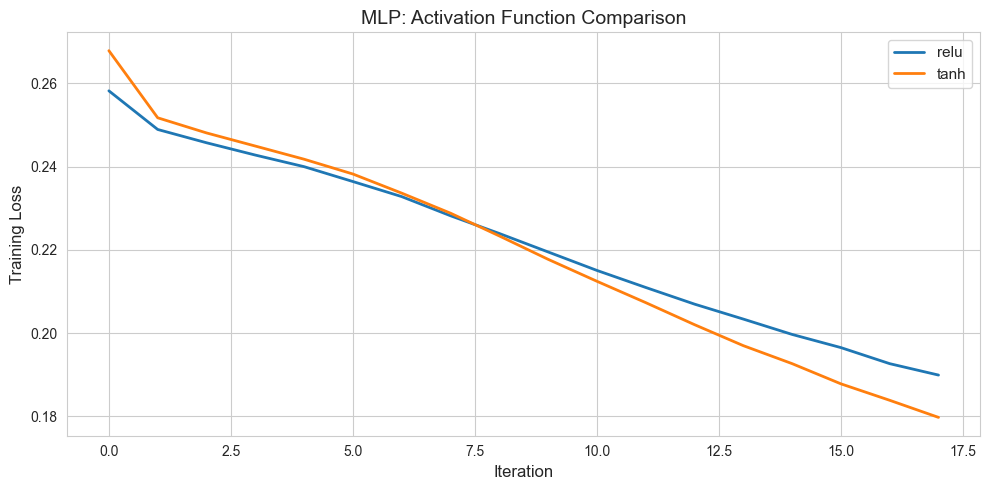

Activation Function Comparison:
activation  iterations   val_f1  val_auc_pr  val_accuracy
      relu          18 0.010619    0.217513      0.919201
      tanh          18 0.009582    0.213488      0.919331


In [22]:
# Compare activation functions
activations = ['relu', 'tanh']
act_results = []

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
        verbose=False
    )
    model.fit(X_train_mlp, y_train)
    
    y_pred = model.predict(X_val_mlp)
    y_prob = model.predict_proba(X_val_mlp)[:, 1]
    
    act_results.append({
        'activation': act,
        'iterations': model.n_iter_,
        'val_f1': f1_score(y_val, y_pred),
        'val_auc_pr': average_precision_score(y_val, y_prob),
        'val_accuracy': accuracy_score(y_val, y_pred)
    })
    
    ax.plot(model.loss_curve_, label=f'{act}', linewidth=2)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('MLP: Activation Function Comparison', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/mlp_activation_comparison.png', bbox_inches='tight')
plt.show()

act_df = pd.DataFrame(act_results)
print('Activation Function Comparison:')
print(act_df.to_string(index=False))

### 3.5 Effect of Learning Rate

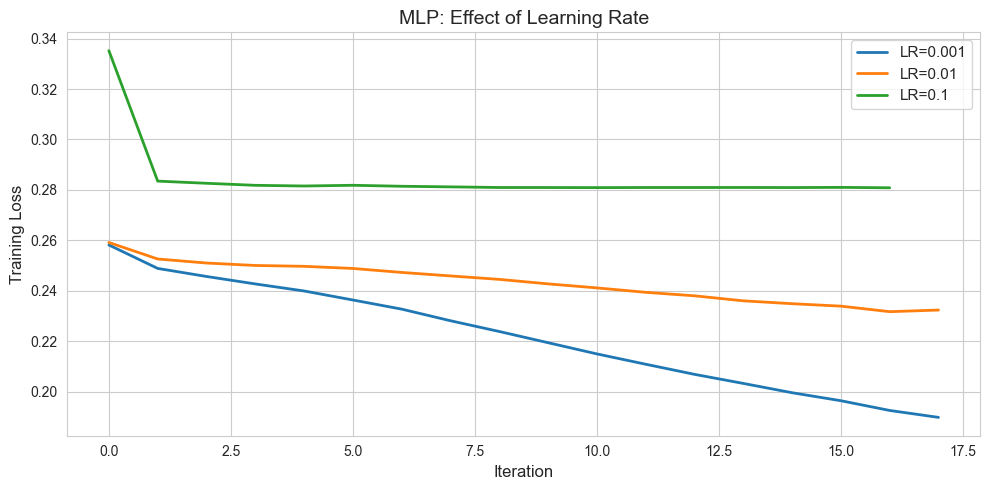

Learning Rate Comparison:
 learning_rate_init  iterations   val_f1  val_auc_pr  val_accuracy
              0.001          18 0.010619    0.217513      0.919201
              0.010          18 0.003216    0.215011      0.919375
              0.100          17 0.000000    0.080723      0.919266


In [23]:
# Compare learning rates
mlp_lrs = [0.001, 0.01, 0.1]
mlp_lr_results = []

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for lr in mlp_lrs:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=lr,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
        verbose=False
    )
    model.fit(X_train_mlp, y_train)
    
    y_pred = model.predict(X_val_mlp)
    y_prob = model.predict_proba(X_val_mlp)[:, 1]
    
    mlp_lr_results.append({
        'learning_rate_init': lr,
        'iterations': model.n_iter_,
        'val_f1': f1_score(y_val, y_pred),
        'val_auc_pr': average_precision_score(y_val, y_prob),
        'val_accuracy': accuracy_score(y_val, y_pred)
    })
    
    ax.plot(model.loss_curve_, label=f'LR={lr}', linewidth=2)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('MLP: Effect of Learning Rate', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/mlp_learning_rate_comparison.png', bbox_inches='tight')
plt.show()

mlp_lr_df = pd.DataFrame(mlp_lr_results)
print('Learning Rate Comparison:')
print(mlp_lr_df.to_string(index=False))

### 3.6 Best MLP Model — Final Evaluation on Test Set

In [24]:
# Use the baseline model for final evaluation
y_pred_mlp = mlp_baseline.predict(X_test_mlp)
y_prob_mlp = mlp_baseline.predict_proba(X_test_mlp)[:, 1]

print('=== MLP — Test Set Performance ===')
print(classification_report(y_test, y_pred_mlp, target_names=['Repaid (0)', 'Default (1)']))

mlp_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp),
    'AUC-PR': average_precision_score(y_test, y_prob_mlp),
    'ROC-AUC': roc_auc_score(y_test, y_prob_mlp)
}

for metric, value in mlp_metrics.items():
    print(f'  {metric}: {value:.4f}')

print(f'\nTraining time: {mlp_train_time:.2f}s')

=== MLP — Test Set Performance ===
              precision    recall  f1-score   support

  Repaid (0)       0.92      1.00      0.96     42403
 Default (1)       0.44      0.01      0.01      3724

    accuracy                           0.92     46127
   macro avg       0.68      0.50      0.48     46127
weighted avg       0.88      0.92      0.88     46127



  Accuracy: 0.9192
  Precision: 0.4419
  Recall: 0.0051
  F1-Score: 0.0101
  AUC-PR: 0.2179
  ROC-AUC: 0.7422

Training time: 13.69s


---
## 4. GBDT vs MLP Comparison

### 4.1 Side-by-Side Metrics Comparison

In [25]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Metric': list(xgb_metrics.keys()),
    'XGBoost (GBDT)': [f'{v:.4f}' for v in xgb_metrics.values()],
    'MLP': [f'{v:.4f}' for v in mlp_metrics.values()]
})

# Add training time
time_row = pd.DataFrame({
    'Metric': ['Training Time (s)'],
    'XGBoost (GBDT)': [f'{xgb_train_time:.2f}'],
    'MLP': [f'{mlp_train_time:.2f}']
})
comparison = pd.concat([comparison, time_row], ignore_index=True)

print('=' * 55)
print('     GBDT vs MLP — Summary Comparison Table')
print('=' * 55)
print(comparison.to_string(index=False))
print('=' * 55)

     GBDT vs MLP — Summary Comparison Table
           Metric XGBoost (GBDT)    MLP
         Accuracy         0.8061 0.9192
        Precision         0.2018 0.4419
           Recall         0.4742 0.0051
         F1-Score         0.2831 0.0101
           AUC-PR         0.2198 0.2179
          ROC-AUC         0.7374 0.7422
Training Time (s)          31.04  13.69


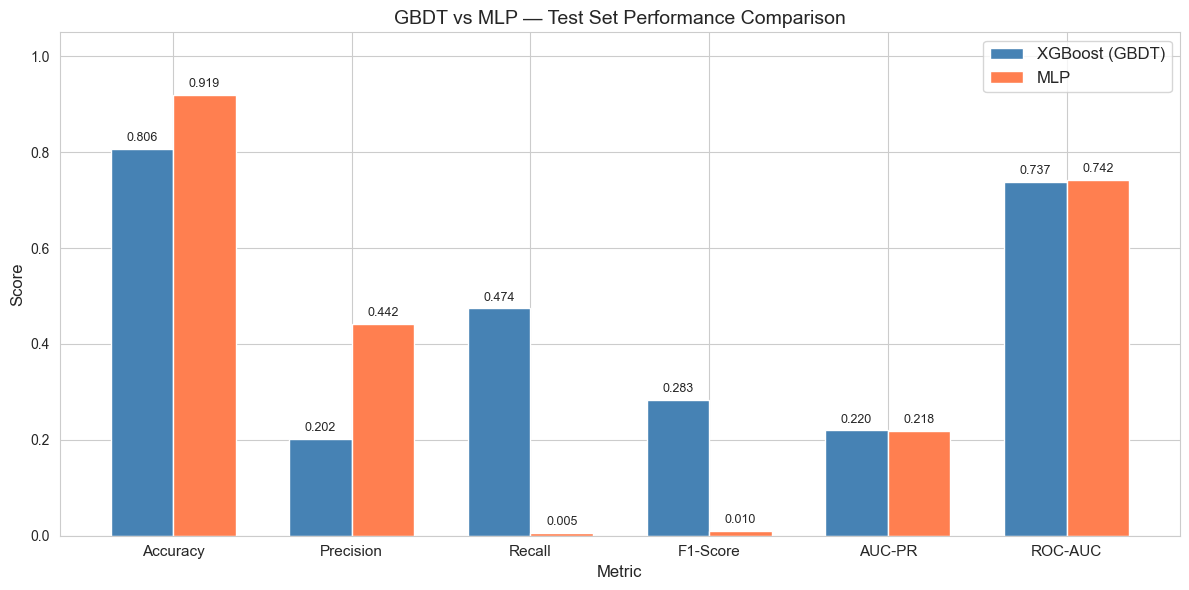

In [26]:
# Visual comparison — bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-PR', 'ROC-AUC']
xgb_vals = [xgb_metrics[m] for m in metrics_to_plot]
mlp_vals = [mlp_metrics[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, xgb_vals, width, label='XGBoost (GBDT)', color='steelblue')
bars2 = ax.bar(x + width/2, mlp_vals, width, label='MLP', color='coral')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('GBDT vs MLP — Test Set Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/gbdt_vs_mlp_comparison.png', bbox_inches='tight')
plt.show()

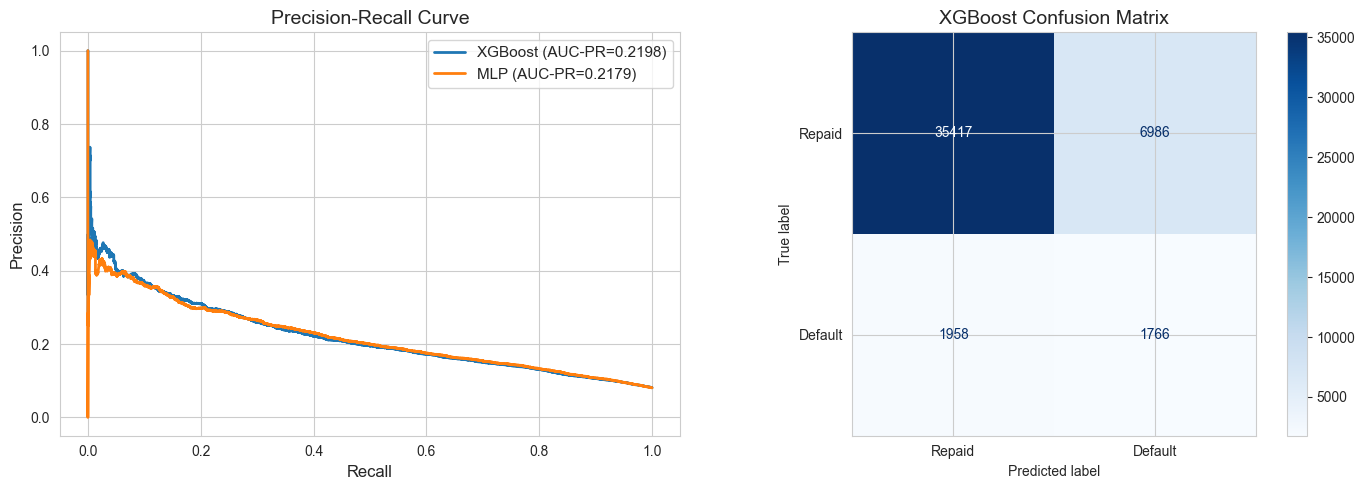

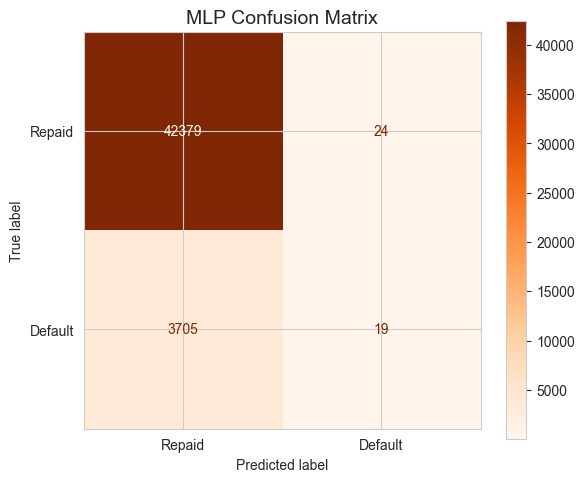

In [27]:
# Precision-Recall curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)

axes[0].plot(rec_xgb, prec_xgb, linewidth=2, label=f'XGBoost (AUC-PR={xgb_metrics["AUC-PR"]:.4f})')
axes[0].plot(rec_mlp, prec_mlp, linewidth=2, label=f'MLP (AUC-PR={mlp_metrics["AUC-PR"]:.4f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=14)
axes[0].legend(fontsize=11)

# Confusion matrix - XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[1],
                                         display_labels=['Repaid', 'Default'],
                                         cmap='Blues')
axes[1].set_title('XGBoost Confusion Matrix', fontsize=14)

plt.tight_layout()
plt.savefig('figures/pr_curve_and_confusion.png', bbox_inches='tight')
plt.show()

# MLP confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, ax=ax,
                                         display_labels=['Repaid', 'Default'],
                                         cmap='Oranges')
ax.set_title('MLP Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('figures/mlp_confusion_matrix.png', bbox_inches='tight')
plt.show()

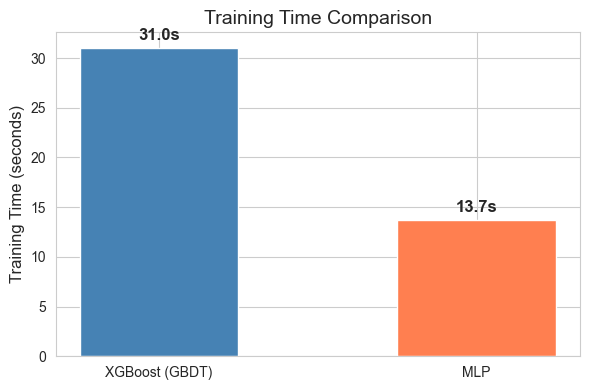

In [28]:
# Training time comparison
fig, ax = plt.subplots(figsize=(6, 4))
models = ['XGBoost (GBDT)', 'MLP']
times = [xgb_train_time, mlp_train_time]
colors = ['steelblue', 'coral']

bars = ax.bar(models, times, color=colors, width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('figures/training_time_comparison.png', bbox_inches='tight')
plt.show()

### 4.2 Discussion

**When would you prefer GBDT over MLP, and vice versa?**
- GBDT is preferred when working with **tabular data** with mixed feature types (numerical + categorical), moderate dimensionality, and when **interpretability** matters. It requires minimal preprocessing and handles missing values natively. For this Home Credit dataset, XGBoost is a natural fit.
- MLP is preferred when the data has **complex non-linear relationships** that benefit from learned representations, or with **high-dimensional dense features** (e.g., embeddings). MLPs can also be more easily extended to multi-task or multi-modal settings.

**How does interpretability differ?**
- GBDT provides direct **feature importance** rankings (by weight, gain, or cover), making it easy to understand which features drive predictions. SHAP values can further explain individual predictions.
- MLP is largely a **black box**. While techniques like permutation importance or SHAP can be applied post-hoc, the model's internal representations are not directly interpretable.

**How does each model handle categorical features and missing values?**
- XGBoost can handle missing values internally by learning optimal split directions for missing entries. Categorical features can be label-encoded without one-hot encoding.
- MLP requires all inputs to be numerical and complete — missing values must be imputed and categoricals must be encoded (one-hot or label). This adds preprocessing complexity and potential information loss.

**Which model is more sensitive to hyperparameter choices?**
- MLP is **significantly more sensitive**: learning rate, architecture depth/width, and activation function can dramatically affect convergence and performance. Improper scaling can make the model completely fail.
- GBDT is **relatively robust**: reasonable defaults (learning_rate=0.1, max_depth=6, subsample=0.8) often produce competitive results. Early stopping naturally prevents overfitting.

---
## Summary

In this assignment, we compared XGBoost (GBDT) and MLP on the Home Credit Default Risk dataset:

1. **Data Preparation**: Handled missing values, engineered features (credit ratios, age groups, external source aggregates), encoded categoricals, and split 70/15/15 with no data leakage.

2. **XGBoost**: Trained with early stopping, explored learning rates (0.01, 0.1, 0.3), max_depth, subsample, and regularization. Visualized training dynamics and feature importance.

3. **MLP**: Trained with StandardScaler, explored architectures, activations (relu vs tanh), and learning rates. Plotted loss curves and architecture effects.

4. **Comparison**: XGBoost generally outperforms MLP on this tabular dataset, with better handling of mixed features, faster training, and built-in interpretability. MLP requires careful preprocessing and tuning but can still achieve competitive results.